In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

# sklearn imports
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import RandomizedSearchCV

# from utils.visualization import standard_setup, BLUE, GREEN
#standard_setup()
BLUE = "steelblue"
GREEN = "darkgreen"

## Define locations

In [2]:
loc_input = os.path.join('..', 'data')
loc_output = os.path.join('..', 'data')

locs = {'train' : os.path.join(loc_input, 'titanic_train.csv'),
        'test' : os.path.join(loc_input, 'titanic_test.csv'),
        'gender_submission' : os.path.join(loc_input, 'titanic_gender_submission.csv')}

## 1 Read & clean data

In [3]:
def preprocess_df_x(df_x):

    # Translate cabin column to cabin vs no cabin
    idx_no_cabin = df_x['Cabin'].isnull()
    df_x.loc[idx_no_cabin, 'Cabin'] = False
    df_x.loc[~idx_no_cabin, 'Cabin'] = True
    df_x['Fare'] = df_x['Fare'].fillna(df_x['Fare'].mean())
    return df_x


df_train = pd.read_csv(locs['train'])

# Drop features that I'm not using
df_train = df_train.drop(['PassengerId', 'Name', 'Ticket'], axis = 1)

df_train = preprocess_df_x(df_train)

# Split X & y
X_train = df_train.drop(['Survived'], axis = 1)
y_train = df_train['Survived']

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Cabin     891 non-null    object 
 8   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


## 2. Train grotere en grotere ensemble methodes

### 2.1 Hyperparameters kiezen

In [5]:
n_estimator_range = range(1, 100)
random_state = 42

### 2.2 Pipeline opzetten voor preprocessing

In [6]:
# Step 1: Define the pipeline steps
ordinal_encode_step = Pipeline(steps=[('ord_encoder', OrdinalEncoder(categories=[[1, 2, 3]]))])
one_hot_encode_step = Pipeline(steps=[('one_hot_encoder', OneHotEncoder(drop='if_binary'))])
impute_step = Pipeline(steps=[('imputer', SimpleImputer(strategy='mean'))])
one_hot_embarked_step = Pipeline(steps=[('impute_embarked', SimpleImputer(strategy='most_frequent')),
                                        ('one_hot_embarked', OneHotEncoder(drop = 'first'))])


# Step 2: Create the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('ord_encode', ordinal_encode_step, ['Pclass']),
        ('one_hot_encode_sex', one_hot_encode_step, ['Sex']),
        ('one_hot_encode_cabin', one_hot_encode_step, ['Cabin']),
        ('impute_age', impute_step, ['Age']),
        ('one_hot_embarked', one_hot_embarked_step, ['Embarked'])
    ],
    remainder='passthrough'
)

In [7]:
# rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

### 2.3 Pipeline afwerken met een ensemble methode en resultaten verzamelen

In [8]:
columns = dict()
for n_estimators in tqdm(n_estimator_range):
    rf_classifier = RandomForestClassifier(n_estimators=n_estimators, random_state=random_state)
    final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                        ('classifier', rf_classifier)])

    y_pred_cv = cross_val_predict(final_pipeline, X_train, y_train, cv=5, method = 'predict_proba')[:, 1]
    columns[f"Estimators: {n_estimators}"] = y_pred_cv

df_predictions = pd.DataFrame(columns)

100%|██████████| 99/99 [00:58<00:00,  1.70it/s]


In [9]:
df_predictions.head()

,Estimators: 1,Estimators: 2,Estimators: 3,Estimators: 4,Estimators: 5,Estimators: 6,Estimators: 7,Estimators: 8,Estimators: 9,Estimators: 10,...,Estimators: 90,Estimators: 91,Estimators: 92,Estimators: 93,Estimators: 94,Estimators: 95,Estimators: 96,Estimators: 97,Estimators: 98,Estimators: 99
0,0.0,0.0,0.000000,0.00,0.1,0.083333,0.071429,0.0625,0.055556,0.05,...,0.163889,0.170330,0.168478,0.166667,0.164894,0.163158,0.161458,0.159794,0.158163,0.156566
1,1.0,1.0,1.000000,1.00,1.0,1.000000,1.000000,1.0000,1.000000,1.00,...,0.988889,0.989011,0.989130,0.989247,0.989362,0.989474,0.989583,0.989691,0.989796,0.989899
2,1.0,0.5,0.333333,0.25,0.4,0.500000,0.428571,0.5000,0.555556,0.60,...,0.555556,0.560440,0.565217,0.569892,0.574468,0.568421,0.562500,0.567010,0.561224,0.565657
3,1.0,1.0,1.000000,1.00,1.0,1.000000,1.000000,1.0000,1.000000,1.00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,0.0,0.0,0.000000,0.00,0.0,0.000000,0.000000,0.0000,0.000000,0.00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### 2.4 Experiment met groter wordende trainingsdata

In [10]:
zoom_in_columns = [1, 5, 10, 20]
results_increasing_data = dict()

for perc_data in tqdm(range(5, 101, 5)):
    for zoom_in_column in zoom_in_columns:
        rf_classifier = RandomForestClassifier(n_estimators=zoom_in_column, 
                                                random_state=random_state)

        final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                            ('classifier', rf_classifier)])

        endpoint = int(0.5 + np.ceil(perc_data / 100 * len(X_train)))

        # Cross validation
        predict_proba_cv = cross_val_predict(final_pipeline, 
                                                X_train.iloc[:endpoint], 
                                                y_train.iloc[:endpoint], 
                                                cv=5, 
                                                method = 'predict_proba')[:, 1]
        
        # Training error
        final_pipeline.fit(X_train.iloc[:endpoint], y_train.iloc[:endpoint])
        predict_proba_train = final_pipeline.predict_proba(X_train.iloc[:endpoint])[:, 1]

        results_increasing_data[perc_data, zoom_in_column] = {'predict_proba_cv' : predict_proba_cv,
                                                                'predict_proba_train' : predict_proba_train,
                                                                'y_act' : y_train.iloc[:endpoint]}

100%|██████████| 20/20 [00:19<00:00,  1.02it/s]


### 3. Resultaten bekijken

### 3.1 AUC evolutie bekijken

In [11]:
colors = {1 : 'darkred', 
                5 : 'darkorange', 
                10 : BLUE, 
                20 : GREEN}

In [12]:
rows = list()
for column in df_predictions.columns:
    y_train_hat_proba = df_predictions[column]
    # Compute AUC
    fpr, tpr, thresholds = roc_curve(y_train, y_train_hat_proba)
    roc_auc = auc(fpr, tpr)
    rows.append({'ensemble_size' : int(column.split(': ')[1]),
                    'roc_auc' : roc_auc})
    df_auc = pd.DataFrame(rows)

<Axes: xlabel='ensemble_size'>

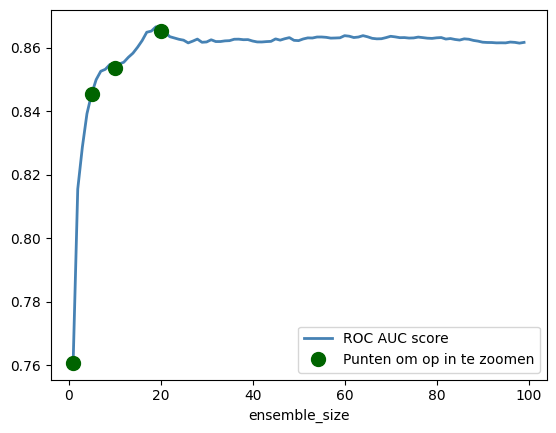

In [13]:
ax = df_auc.plot(x = 'ensemble_size', 
                y = 'roc_auc', 
                color = BLUE,
                lw = 2,
                label = 'ROC AUC score')

df_auc.query("ensemble_size in @zoom_in_columns").plot(x = 'ensemble_size', 
                                                            y = 'roc_auc', 
                                                            color = GREEN,
                                                            ls = '',
                                                            marker = 'o',
                                                            markersize = 10,
                                                            label = "Punten om op in te zoomen",
                                                            ax = ax)

### 3.2 ROC curve bekijken

C:\Users\Cursist\AppData\Local\Temp\ipykernel_13240\1148779191.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right")


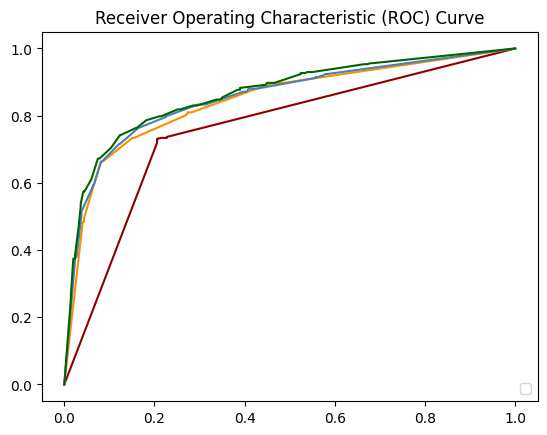

In [14]:
fig, ax = plt.subplots()
rows = list()
for column in df_predictions.columns:
    ensemble_size = int(column.split(': ')[1])
    if ensemble_size not in zoom_in_columns:
        continue

    y_train_hat_proba = df_predictions[column]
    # Compute AUC
    fpr, tpr, thresholds = roc_curve(y_train, y_train_hat_proba)
    
    ax.plot(fpr, 
                tpr, 
                color = colors[ensemble_size])

ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.set_title('Receiver Operating Characteristic (ROC) Curve')
ax.legend(loc="lower right")

### 3.3 Learning curves (handmatige implementatie)

In [15]:
rows = list()
for (perc_data, n_estimators), results in results_increasing_data.items():
    y_train = results['y_act']

    fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_train, results['predict_proba_cv'])
    fpr_train, tpr_train, thresholds_train = roc_curve(y_train, results['predict_proba_train'])

    rows.append({'score_cv' : auc(fpr_cv, tpr_cv),
                    'score_train' : auc(fpr_train, tpr_train),
                    'perc_data' : perc_data,
                    'n_estimators' : n_estimators})

df_train_vs_test = pd.DataFrame(rows)

Text(0, 0.5, 'ROC AUC Score')

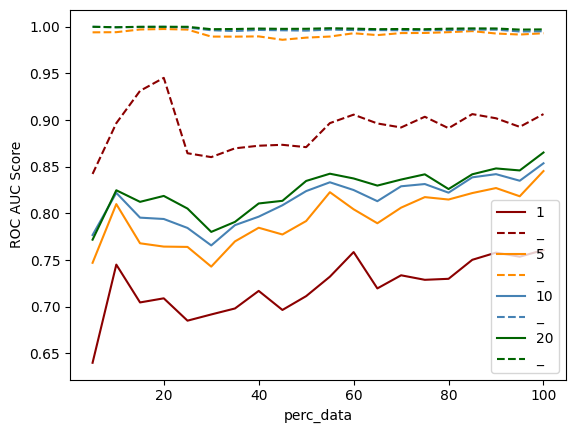

In [16]:
fig, ax = plt.subplots()
for ensemble_size, group in df_train_vs_test.groupby('n_estimators'):
    group.plot(x = 'perc_data',
                    y = 'score_cv',
                    ax = ax,
                    color = colors[ensemble_size],
                    label = ensemble_size)

    group.plot(x = 'perc_data',
                    y = 'score_train',
                    ax = ax,
                    color = colors[ensemble_size],
                    ls = '--',
                    label = "_")

ax.set_ylabel("ROC AUC Score")

### 4. Overfitten proberen tegen te gaan

### 4.1 Zelf wat proberen te regularizeren

In [17]:
# Create a Random Forest classifier with regularization
rf_classifier_regularized = RandomForestClassifier(n_estimators=100, 
                                                   max_depth=2,  # Limit the depth of trees
                                                   min_samples_split=5,  # Set the minimum samples split
                                                   min_samples_leaf=2,  # Set the minimum samples per leaf
                                                   max_features='sqrt',  # Limit the number of features to consider
                                                   random_state=42)

final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                        ('classifier', rf_classifier_regularized)])

# Cross validatie
predict_proba_cv = cross_val_predict(final_pipeline, 
                                        X_train, 
                                        y_train, 
                                        cv=5, 
                                        method = 'predict_proba')[:, 1]

# Trainings-score
final_pipeline.fit(X_train, y_train)
predict_proba_train = final_pipeline.predict_proba(X_train)[:, 1]

# Bereken ROC AUC scores
fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_train, predict_proba_cv)
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, predict_proba_train)

print(f"ROC AUC train: {auc(fpr_train, tpr_train)}")
print(f"ROC AUC cv: {auc(fpr_cv, tpr_cv)}")


## Resultaten wegeschrijven
X_test = pd.read_csv(locs['test'])
predictions = final_pipeline.predict(preprocess_df_x(X_test))

df_out = pd.DataFrame({'PassengerId' : X_test.PassengerId.values, 
                                'Survived' : predictions})

df_out.to_csv(os.path.join(loc_output, "submission_rf.csv"), index = False)

ROC AUC train: 0.8610924700944833
ROC AUC cv: 0.8464566090392953


### 4.2 Randomized search doen

In [ ]:
# Define the hyperparameters to search over
param_dist = {
    "classifier__n_estimators": [5, 10, 20, 30, 40, 50, 100, 200],
    "classifier__max_depth": [2, 3, 4, 5, 10],
    "classifier__min_samples_split": [2, 3, 4, 5, 10],
    "classifier__min_samples_leaf": [2, 3, 4, 8]
}

# Create the pipeline with preprocessing and classifier
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Perform randomized search with tqdm progress bar
n_iter_search = 100  # Number of parameter settings that are sampled
random_search = RandomizedSearchCV(final_pipeline, 
                                        param_distributions=param_dist, 
                                        n_iter=n_iter_search, 
                                        cv=5, 
                                        random_state=42)

# Create a tqdm wrapper for the randomized search
with tqdm(total=n_iter_search, desc="RandomizedSearchCV") as pbar:
    random_search.fit(X_train, y_train)
    pbar.update(n_iter_search)

# Get the best hyperparameters
best_params = random_search.best_params_
print("Best hyperparameters:", best_params)

# Get the best model
best_model = random_search.best_estimator_

# Cross-validated predictions
predict_proba_cv = cross_val_predict(best_model, X_train, y_train, cv=5, method='predict_proba')[:, 1]

# Training score
best_model.fit(X_train, y_train)
predict_proba_train = best_model.predict_proba(X_train)[:, 1]

# Calculate ROC AUC scores
fpr_cv, tpr_cv, thresholds_cv = roc_curve(y_train, predict_proba_cv)
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, predict_proba_train)

print(f"ROC AUC train: {auc(fpr_train, tpr_train)}")
print(f"ROC AUC cv: {auc(fpr_cv, tpr_cv)}")

RandomizedSearchCV:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
## Resultaten wegeschrijven
X_test = pd.read_csv(locs['test'])
predictions = best_model.predict(preprocess_df_x(X_test))

df_out = pd.DataFrame({'PassengerId' : X_test.PassengerId.values, 
                                'Survived' : predictions})

df_out.to_csv(os.path.join(loc_output, "submission_rf_best.csv"), index = False)

Hier hebben we een relatief eenvoudige oplossing voor een klassiek probleem uit de doeken gedaan. Een meer complexe oplossing (met betere resultaten) vind je in `02 titanic-top-4-with-ensemble-modeling.ipynb`. Hoeveel moeite je wil doen om je oplossing zo goed mogelijk wil krijgen is steeds een afweging tussen tijdsinvestering en performance die gemaakt moet worden in samenspraak met de projectleider.